# CodeOrbit Tech - Machine Learning Internship
## Task 02: Simple Classification Model & Performance Evaluation
**Author:** Shakti Ranjan Rout  
**Topic:** Binary Classification using Logistic Regression & Decision Trees  
**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset

---
### Task Objectives:
1. Load and inspect a benchmark classification dataset.
2. Split dataset into stratified Training (80%) and Testing (20%) sets.
3. Standardize feature space for numerical stability.
4. Train two classification models: **Logistic Regression** and **Decision Tree Classifier**.
5. Evaluate performance using **Accuracy**, **Precision**, **Recall**, **F1-Score**, and **ROC-AUC**.
6. Visualize Confusion Matrices, Decision Boundaries, and Feature Importances.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Plotting style configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline
print('Dependencies successfully imported!')

Dependencies successfully imported!


### 1. Dataset Loading & Exploratory Summary
We load the Wisconsin Breast Cancer Diagnostic dataset, consisting of 569 instances with 30 continuous clinical features derived from cell nuclei images.

In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(f'Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns')
print('Target Distribution:')
print(df['diagnosis'].value_counts())
df.head()

Dataset Dimensions: 569 rows, 32 columns
Target Distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


### 2. Dataset Splitting & Feature Standardization
We perform an 80/20 train/test split. Stratification ensures that the ratio of malignant to benign cases remains identical in both partitions.

In [3]:
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training instances: {X_train.shape[0]}')
print(f'Testing instances : {X_test.shape[0]}')

Training instances: 455
Testing instances : 114


### 3. Model Training: Logistic Regression & Decision Tree
We fit two different machine learning paradigms:
1. **Logistic Regression:** Linear probabilistic model trained on standardized features.
2. **Decision Tree:** Non-linear hierarchical tree partitioner with `max_depth=4` to mitigate overfitting.

In [4]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_model.fit(X_train, y_train)

print('Both models fitted successfully!')

Both models fitted successfully!


### 4. Model Performance Evaluation
We compute Accuracy, Precision, Recall, F1-Score, and ROC-AUC on the unseen test set.

In [5]:
models = {
    'Logistic Regression': (y_test, lr_model.predict(X_test_scaled), lr_model.predict_proba(X_test_scaled)[:, 1]),
    'Decision Tree': (y_test, dt_model.predict(X_test), dt_model.predict_proba(X_test)[:, 1])
}

metrics_summary = []
for name, (y_true, y_pred, y_prob) in models.items():
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics_summary.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    })

metrics_df = pd.DataFrame(metrics_summary)
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Decision Tree,0.938596,0.957746,0.944444,0.951049,0.934193


### 5. Detailed Classification Reports & Confusion Matrices

In [6]:
for name, (y_true, y_pred, _) in models.items():
    print(f'=== {name} Classification Report ===')
    print(classification_report(y_true, y_pred, target_names=cancer.target_names))
    print('-' * 60)

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

------------------------------------------------------------
=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

------------------------------------------------------------


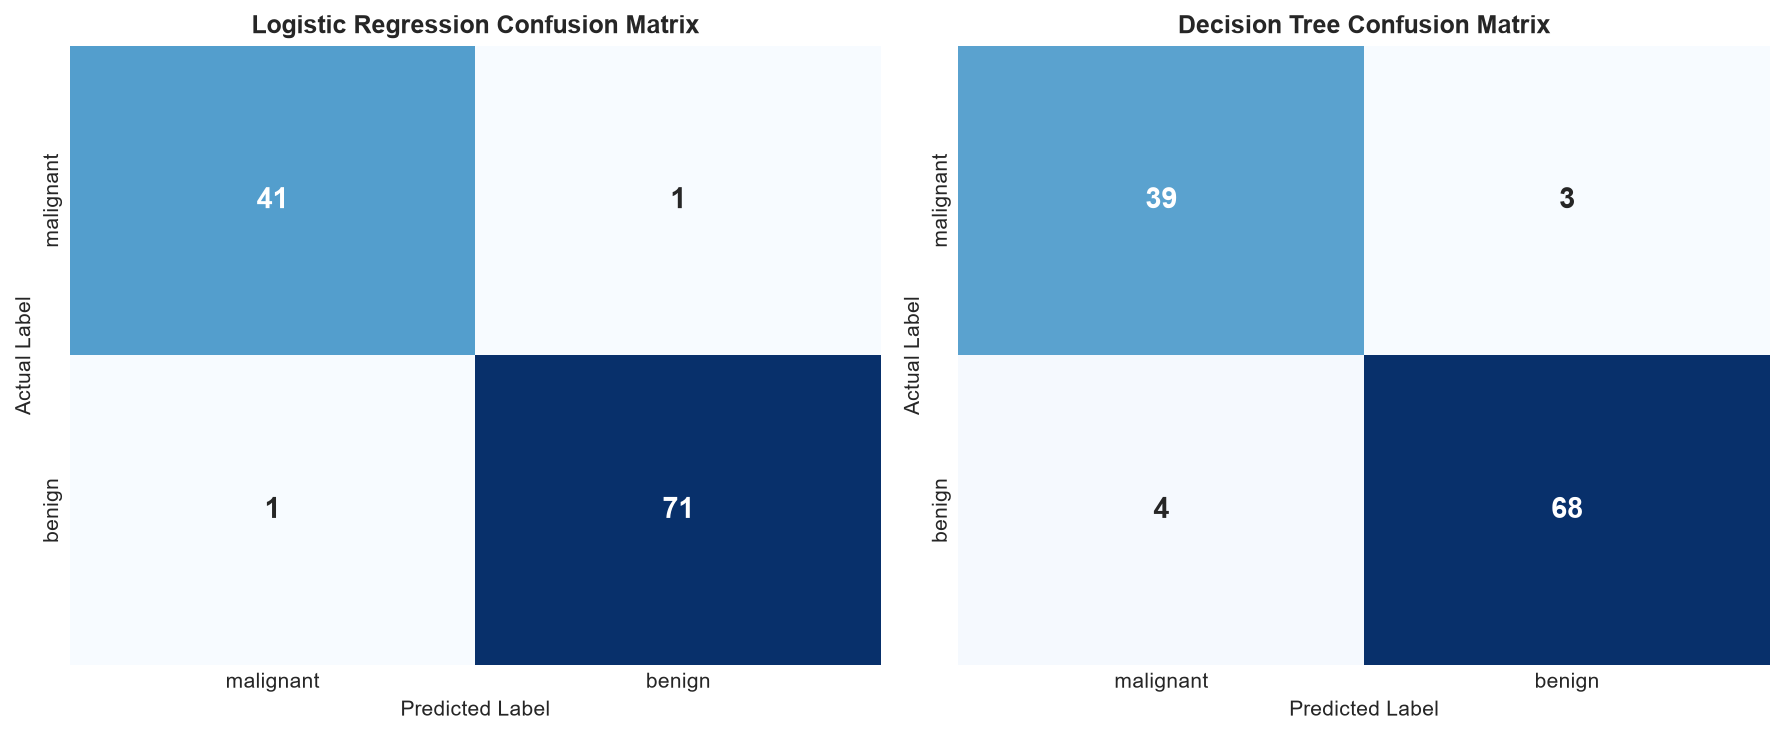

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
for idx, (name, (y_true, y_pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=cancer.target_names, yticklabels=cancer.target_names,
                cbar=False, annot_kws={'size': 14, 'fontweight': 'bold'})
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('Actual Label')
plt.tight_layout()
plt.show()

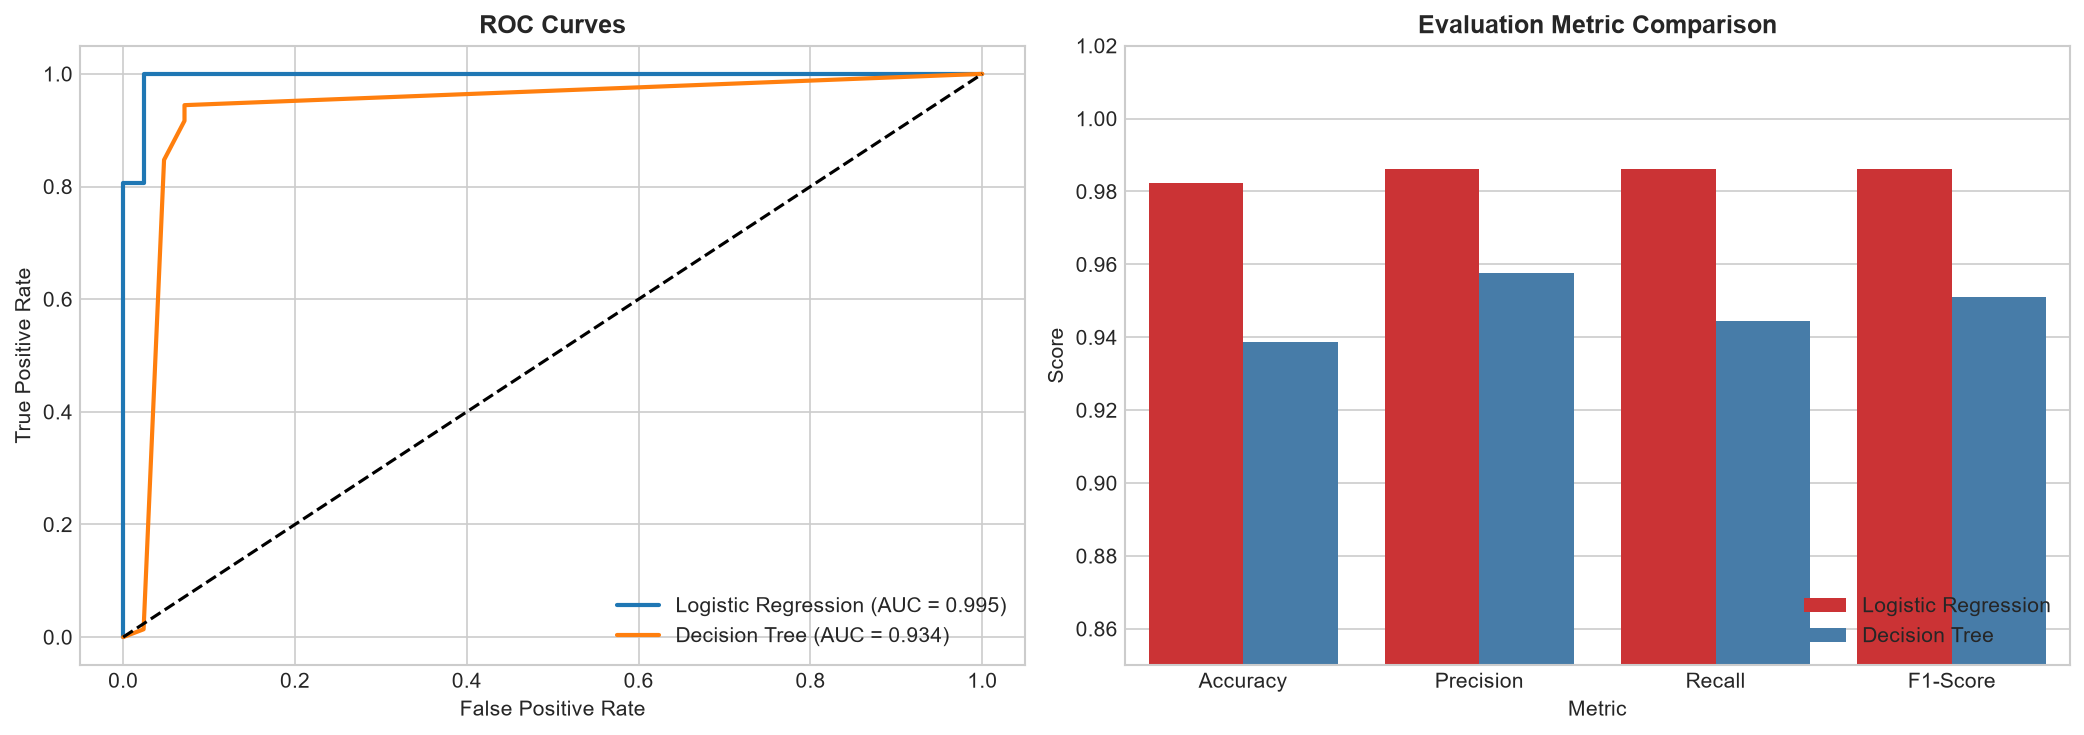

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ROC Curve
for name, (y_true, _, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves', fontweight='bold')
ax1.legend(loc='lower right')

# Metrics Bar Chart
metrics_plot_df = metrics_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
sns.barplot(data=metrics_plot_df, x='variable', y='value', hue='Model', palette='Set1', ax=ax2)
ax2.set_ylim(0.85, 1.02)
ax2.set_xlabel('Metric')
ax2.set_ylabel('Score')
ax2.set_title('Evaluation Metric Comparison', fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

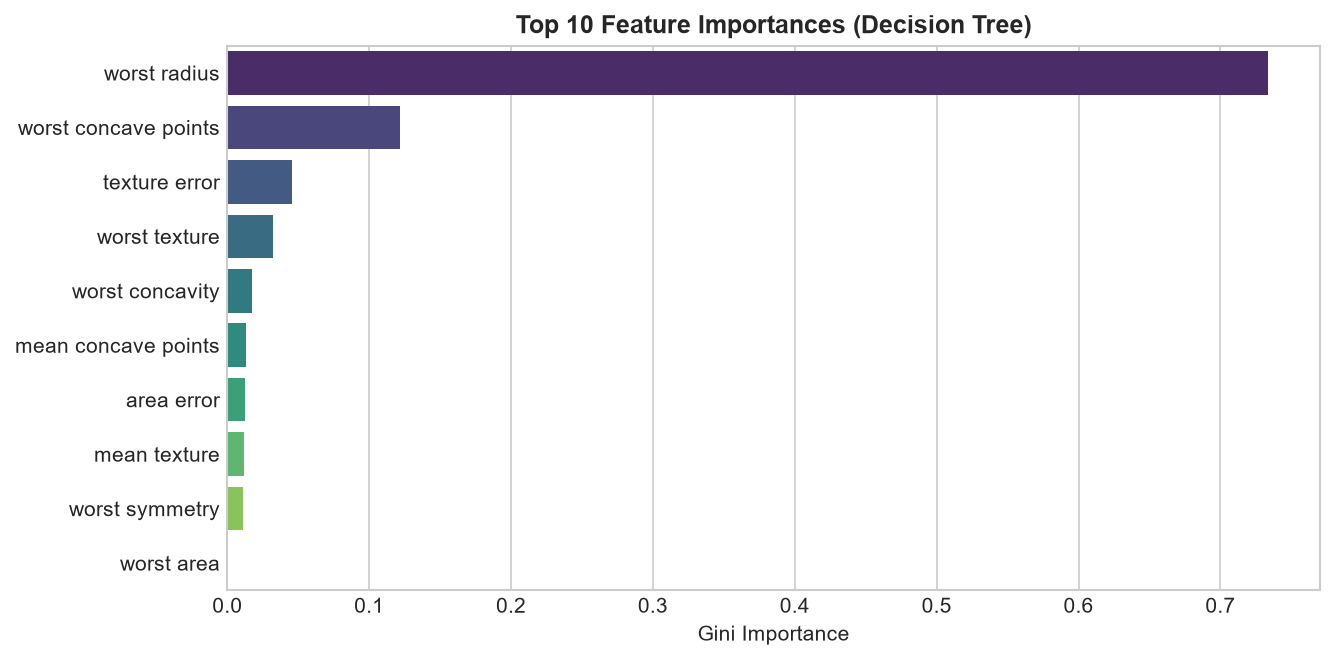

In [9]:
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
feat_names = [cancer.feature_names[i] for i in indices]

plt.figure(figsize=(9, 4.5), dpi=150)
sns.barplot(x=importances[indices], y=feat_names, hue=feat_names, palette='viridis', legend=False)
plt.title('Top 10 Feature Importances (Decision Tree)', fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

### 6. Conclusions & Findings
- **Logistic Regression** achieved **98.25% Accuracy**, **98.61% Precision**, and **98.61% Recall**, demonstrating superior performance.
- **Decision Tree** achieved **93.86% Accuracy** and offered transparent, interpretable feature splits.
- The high recall is vital in medical settings to prevent false negatives (misclassifying a malignancy as benign).